# Creating spectroscopic look-up tables

ArchNEMESIS includes functionality to create line-by-line or correlated-k look-up tables compatible with both archNEMESIS and NEMESIS. These programs are based on the spectroscopic calculations made with the LineData class, so we also encourage the users to also explore this [tutorial](https://archnemesis.readthedocs.io/en/latest/examples/linedata/linedata.html) to better understand how the calculations are performed. 

In this notebook, we provide some examples showing how archNEMESIS can be used to create these look-up tables.

In [1]:
import archnemesis as ans
import matplotlib.pyplot as plt
import numpy as np
from archnemesis.Data.path_data import archnemesis_path

## 1. Creating a line-by-line look-up table

We are going to create a look-up table for the main isotope of CO (ID=5, ISO=1) using spectroscopic line data from HITRAN2024, together with the partition sums from TIPS2025.

The main function for creating these look-up tables is called *calc_lbltable()* and is stored in the Spectroscopy_0.py file. A description of the input parameters is defined below:

In [2]:
help(ans.calc_lbltable)

Help on function calc_lbltable in module archnemesis.Spectroscopy_0:

calc_lbltable(outname, gasID, isoID, npress, p0, pn, ntemp, t0, tn, ispace, nwave, wavemin, delwave, iproc, wn_calc_window, wn_approx_window, self_frac, line_database, pf_database='/home/alday/Documents/Projects/archnemesis-dist/archnemesis/Data/partition_functions/tips2025.h5', cont_database=None, include_pressure_shift=True)
    Calculate a line-by-line look-up table for a given gas
    at specified pressure and temperature levels
    
    Input parameters
    -----------------
    @param gasID: int
        Nemesis gas identifier
    @param isoID: int
        Nemesis isotopologue identifier
    @param npress: int
        Number of pressure levels
    @param p0: float
        Minimum pressure level (atm)
    @param pn: float
        Maximum pressure level (atm)
    @param ntemp: int
        Number of temperature levels
    @param t0: float
        Minimum temperature level (K)
    @param tn: float
        Maximum te

In [3]:
#lbl-table inputs
################################################################################

#CO
gasID = 5 ; isoID = 1
outname = "example_co"
 
npress = 10 ; p0 = 1.0e-6 ; pn = 1.0e-2
ntemp = 10 ; t0 = 130. ; tn = 250.

ispace = 0   #wavenumber (cm-1)
vmin = 2050. ; delv = 0.001 ; nwave = 12001

iproc = 0             #Voigt lineshape
wn_calc_window = 25.  #Caclculation window (cm-1)
wn_approx_window = 75.  #Caclculation window (cm-1)
self_frac = 0.5       #fraction of self-broadening

line_base = archnemesis_path()+"/tests/files/linedata/CO_1_ambient_AIR.h5"
pf_base = archnemesis_path()+'/archnemesis/Data/partition_functions/tips2025.h5'
 
#Performing calculations
###################################################################################

#Calculating lbl-table
ans.calc_lbltable(outname,                       #Name of the output .lta file
                  gasID,isoID,                   #Gas information
                  npress,p0,pn,                  #Pressure grid
                  ntemp,t0,tn,                   #Temperature grid
                  ispace,nwave,vmin,delv,        #Wavenumber grid
                  iproc,                         #Lineshape identifier
                  wn_calc_window,                #Wavenumber calculation window (cm-1)
                  wn_approx_window,              #Wavenumber window at which an approximation for the wings is applied (cm-1)
                  self_frac,                     #Self-broadening fraction
                  line_base,                     #Database
                  pf_database=pf_base,           #Partition function database (default = TIPS2025)
                  cont_database=None,            #Pseudo-continuum database (If not None, it will use the same as the line_database)
                  include_pressure_shift=True,   #Flag to include pressure shift in the waveumbers
)

INFO :: read_tables :: Spectroscopy_0.py-1467 :: Reading tables
INFO :: read_tables :: Spectroscopy_0.py-1474 :: RUNTIME calculation is loading desired wavenumber range from databases
INFO :: read_tables :: Spectroscopy_0.py-1480 :: Reading table self.LOCATION_LD[igas]='/home/alday/Documents/Projects/archnemesis-dist/tests/files/linedata/CO_1_ambient_AIR.h5' wavemin=2050.0 wavemax=2062.0


LineData_0::fetch_partition_fn()
Actually getting the partition function
LineData_0::fetch_partition_fn()
Actually getting the partition function


INFO :: calc_klbl_online :: Spectroscopy_0.py-2113 :: Gas 5, Isotope 1 - Calculating line-by-line cross sections at runtime...
/home/alday/Documents/Projects/archnemesis-dist/archnemesis/LineData_0.py:331: NumbaWarning: Cannot cache compiled function "add_line_set_monochromatic_spectrum" as it uses dynamic globals (such as ctypes pointers and large global arrays)
  add_line_set_monochromatic_spectrum(
/home/alday/Documents/Projects/archnemesis-dist/archnemesis/LineData_0.py:331: NumbaWarning: Cannot cache compiled function "voigt_scipy" as it uses dynamic globals (such as ctypes pointers and large global arrays)
  add_line_set_monochromatic_spectrum(
/home/alday/Documents/Projects/archnemesis-dist/archnemesis/LineData_0.py:267: NumbaWarning: Cannot cache compiled function "add_line_set_monochromatic_absorption" as it uses dynamic globals (such as ctypes pointers and large global arrays)
  @njit(parallel=False, cache=MODULE_NUMBA_CACHE)
INFO :: calc_klbl_online :: Spectroscopy_0.py-2113

In [4]:
#Reading the table
#Initialising spectroscopy class with ILBL = 2 (line-by-line)
Spectroscopy = ans.Spectroscopy_0(ILBL=2)

Spectroscopy.NGAS = 1  #We define two gases in the class
Spectroscopy.LOCATION = [outname+'.lta']

#Reading the header information
Spectroscopy.read_header()

#Printing summary information
Spectroscopy.summary_info()

INFO :: summary_info :: Spectroscopy_0.py-461 :: 
#===== SUMMARY =====#
	Spectroscopy_0 instance at memory location 137823132052432
	Calculation type ILBL ::  (<SpectralCalculationModeEnum.LINE_BY_LINE_TABLES: 2>, ' (line-by-line)')
	Number of radiatively-active gaseous species ::  1
	Gaseous species ::  ['CO (1)']
	Number of spectral points ::  12001
	Wavelength range ::  (np.float64(2050.0), '-', np.float64(2062.0))
	Step size ::  0.0010000000002037268
	Number of temperature levels ::  10
	Temperature range ::  (np.float32(130.0), '-', np.float32(250.0))
	Number of pressure levels ::  10
	Pressure range ::  (np.float32(1e-06), '-', np.float32(0.01))
#===================#


INFO :: read_tables :: Spectroscopy_0.py-1467 :: Reading tables
INFO :: read_tables :: Spectroscopy_0.py-1524 :: Reading table self.LOCATION[igas]='example_co.lta' wavemin=0.0 wavemax=10000000000.0


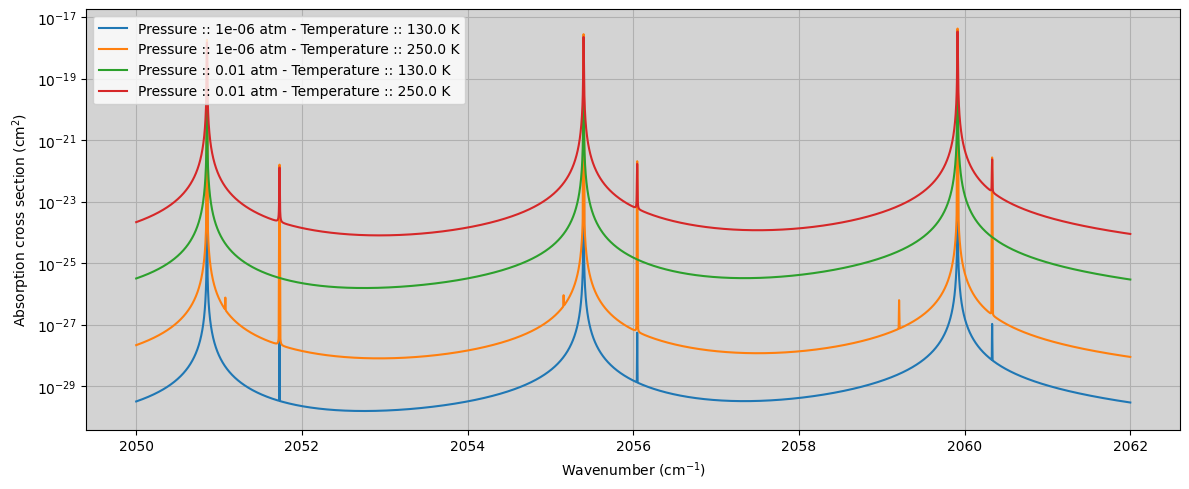

In [6]:
#Reading the information in the lbl-tables in a specified spectral range
Spectroscopy.read_tables()

fig,(ax) = plt.subplots(Spectroscopy.NGAS,1,figsize=(12,5),sharex=True)


ipress = 0 ; itemp = 0
ax.plot(Spectroscopy.WAVE,Spectroscopy.K[:,ipress,itemp,0],label='Pressure :: '+str(Spectroscopy.PRESS[ipress])+' atm - Temperature :: '+str(Spectroscopy.TEMP[itemp])+' K')

ipress = 0 ; itemp = -1
ax.plot(Spectroscopy.WAVE,Spectroscopy.K[:,ipress,itemp,0],label='Pressure :: '+str(Spectroscopy.PRESS[ipress])+' atm - Temperature :: '+str(Spectroscopy.TEMP[itemp])+' K')

ipress = -1 ; itemp = 0
ax.plot(Spectroscopy.WAVE,Spectroscopy.K[:,ipress,itemp,0],label='Pressure :: '+str(Spectroscopy.PRESS[ipress])+' atm - Temperature :: '+str(Spectroscopy.TEMP[itemp])+' K')

ipress = -1 ; itemp = -1
ax.plot(Spectroscopy.WAVE,Spectroscopy.K[:,ipress,itemp,0],label='Pressure :: '+str(Spectroscopy.PRESS[ipress])+' atm - Temperature :: '+str(Spectroscopy.TEMP[itemp])+' K')



ax.set_yscale('log')
ax.set_ylabel('Absorption cross section (cm$^2$)')
ax.legend()
ax.grid()
ax.set_facecolor('lightgray')
ax.set_xlabel('Wavenumber (cm$^{-1}$)')
plt.tight_layout()
